# ENGR 1451/2451 — Weekly Assignment 4
**10 points**

This assignment applies measurement-error ideas, pandas data manipulation, and scatterplots and time trends.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

All data are synthetic teaching examples. LE4-1 and LE4-2 use data embedded in this notebook.
For LE4-3 and LE4-4, place the supplied `buildings.csv` file in a `data/` subfolder beside this notebook:

```text
LE04.ipynb
data/
    buildings.csv
```

Run the notebook with its containing folder as the working directory so that
`data/buildings.csv` points to the supplied file.

Use sample standard deviation $s$ (`ddof=1`). Select rows by conditions, not row positions,
and calculate counts and the latest year from the data. Use the supplied settings for thresholds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

## LE4-1. Comparing two measuring instruments (2 pts)

Two instruments repeatedly measure the same reference block. Treat its certified length,
**25.000 mm**, as exact for this exercise.

### A. Precision and estimated bias (1 pt)

Create a table showing the **mean**, **sample standard deviation**, and **estimated bias**
for each instrument. Here, estimated bias is the sample mean minus the reference length.
Which instrument is more precise? Which sample mean is closer to the reference?

**Answer:**

1. Which instrument is more precise?

The first instrument is more precise because it has a lower standard deviation compared with the second instrument. However, it has a nonzero bias, which means that its measurements are not centered on the true reference value.

2. Which sample mean is closer to the reference?

The second instrument has a mean value closer to the true reference value, since its estimated bias is zero.


In [2]:
reference_mm = 25.000
calibration = pd.DataFrame({
    "A_mm": [25.12, 25.10, 25.14, 25.11, 25.13,
             25.09, 25.12, 25.11, 25.13, 25.10],
    "B_mm": [24.92, 25.06, 24.97, 25.12, 24.89,
             25.03, 25.08, 24.95, 25.00, 24.98],
})

# Your summary table here. Report lengths, s, and estimated bias in mm.
summary = pd.DataFrame ({
    "mean" : calibration.mean(),
    "std" : calibration.std(),
})

summary["bias"] = summary["mean"] - reference_mm

print(summary)

        mean       std   bias
A_mm  25.115  0.015811  0.115
B_mm  25.000  0.072725  0.000


### B. Apply a calibration correction (1 pt)

Subtract A's estimated bias from every A reading and store the result in `corrected_A`.
Compare its mean and sample $s$ with the original A readings.

What changed, and what stayed the same? Would simply collecting more **uncorrected**
readings remove a persistent bias?

**Answer:**

1. What changed, and what stayed the same?

With this adjustment, the mean value of Instrument A changes and the estimated bias becomes zero, as expected. However, the standard deviation stays the same. This means that correcting for the known bias improves the accuracy of the measurements, while the precision remains unchanged.

2. Would simply collecting more **uncorrected** readings remove a persistent bias?

No. Collecting more data would not remove the bias because the bias is inherent to the measurement process or instrument rather than caused by random variation in the data. Collecting more measurements can provide a more reliable estimate of the mean and reduce the standard error, but a persistent bias will remain unless the instrument is calibrated or corrected.

In [3]:
A_bias = summary["bias"].iloc[0]

corrected_A = calibration["A_mm"] - A_bias

summary.loc["corrected_A"] = [
    corrected_A.mean(),
    corrected_A.std(),
    corrected_A.mean() - reference_mm
]

summary

,mean,std,bias
A_mm,25.115,0.015811,0.115
B_mm,25.000,0.072725,0.000
corrected_A,25.000,0.015811,0.000


## LE4-2. Investigating unusual resistance readings (3 pts)

An instrument repeatedly measures the same nominal 100-ohm resistor under stable conditions.
Its exact resistance is unknown. An independent equipment log documents a **loose electrical
lead during one reading**; the other readings have no documented fault.

### A. Flag observations for investigation (1 pt)

Calculate $Q_1$, $Q_3$, and the IQR. Flag readings outside
$[Q_1-1.5\,\mathrm{IQR},\ Q_3+1.5\,\mathrm{IQR}]$ with a Boolean mask called `is_outlier`.
Display their reading IDs, resistance values, and log status. Use `.loc[]` and retain the original data.

In [4]:
resistance_values = np.array([
    100.1, 99.9, 100.0, 100.2, 100.1, 99.8, 100.0, 100.1, 102.4, 99.9,
    100.2, 100.0, 99.8, 100.1, 100.0, 100.2, 100.1, 101.1, 99.9, 100.0,
])
log_status = [
    "none", "none", "none", "none", "none", "none", "none", "none", "loose_lead", "none",
    "none", "none", "none", "none", "none", "none", "none", "none", "none", "none",
]
readings = pd.DataFrame({
    "reading_id": [f"R{number:02d}" for number in range(1, len(resistance_values) + 1)],
    "resistance_ohm": resistance_values,
    "log_status": log_status,
})
resistance_settings = {
    "outlier_multiplier": 1.5,
    "fault_status": "loose_lead",
    "lower_ohm": 99.8,
    "upper_ohm": 100.2,
}

# Your IQR calculation, Boolean mask, and flagged-reading table here
q1 = readings["resistance_ohm"].quantile(0.25)
q3 = readings["resistance_ohm"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - resistance_settings["outlier_multiplier"] * iqr
upper_bound = q3 + resistance_settings["outlier_multiplier"] * iqr

is_outlier = (
    (readings["resistance_ohm"] < lower_bound) |
    (readings["resistance_ohm"] > upper_bound)
)

flagged_readings = readings.loc[
    is_outlier,
    ["reading_id", "resistance_ohm", "log_status"]
]

flagged_readings

,reading_id,resistance_ohm,log_status
8,R09,102.4,loose_lead
17,R18,101.1,none


### B. Exclude a documented failure (1 pt)

Create `retained_readings` by excluding **only the reading with the logged loose lead**.
Select it by `log_status`, not by its row position or resistance value.
Compare the count, mean, and sample $s$ for all readings and the retained readings in one table.

Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?
Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.

**Answer:**

1. Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?

After excluding the reading with the documented loose lead, the mean decreased from 100.195 ohm to 100.079 ohm, which is an absolute change of about 0.116 Ω. The standard deviation decreased from 0.584 ohm to 0.276 ohm, which is an absolute change of about 0.308 ohm. Therefore, the change in the standard deviation is larger.

Removing the faulty reading reduces the spread of the measurements substantially because the 102.4 ohm observation was far from most of the other readings. The mean also decreases, but by a smaller amount.

2. Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.

No. Although the IQR method also flags R18 as unusual, an IQR flag alone is not enough evidence to remove the observation. Unlike the reading with the loose lead, there is no documented measurement failure associated with R18. It may represent a legitimate but unusual measurement, so it should be investigated rather than automatically excluded.

In [5]:
retained_readings = readings[readings["log_status"] != "loose_lead"]

comparison = pd.DataFrame({
    "count" : [readings["reading_id"].count(), retained_readings["reading_id"].count()],
    "mean"  : [readings["resistance_ohm"].mean(), retained_readings["resistance_ohm"].mean()],
    "std"   : [readings["resistance_ohm"].std(), retained_readings["resistance_ohm"].std()]
}, index=["regular_readings", "retained_readings"])

comparison

,count,mean,std
regular_readings,20,100.195000,0.584425
retained_readings,19,100.078947,0.276041


### C. Check a normal approximation (1 pt)

Use **all retained readings from Part B**, including any still flagged by the IQR rule.
Fit a normal model using their calculated mean and sample $s$.

For the interval **99.8 to 100.2 ohms, including both endpoints**, report the observed
percentage using a Boolean mask and the normal-model percentage using `norm.cdf()`.
Is the model percentage too low, too high, or close for this interval?
Why would even a good normal fit fail to establish that the instrument is unbiased?

**Answer:**

1. Is the model percentage too low, too high, or close for this interval?

The observed percentage of retained readings between 99.8 and 100.2, including both endpoints, is approximately 94.74%. The fitted normal model predicts approximately 51.34% of readings within this interval. Therefore, the normal-model percentage is much too low compared with the observed percentage.

This difference occurs because most of the measurements are tightly concentrated between 99.8 and 100.2, while the unusual 101.1 reading increases the sample standard deviation. As a result, the fitted normal distribution is more spread out than most of the observed data.

2. Why would even a good normal fit fail to establish that the instrument is unbiased?

Even if the normal model fit the data well, this would not establish that the instrument is unbiased. A normal distribution describes the shape and spread of the measurements, but bias concerns whether the center of the measurements corresponds to the true resistance. Since the exact resistance of the resistor is unknown, we cannot determine whether the instrument's mean is centered on the true value.

In [6]:
mean = retained_readings["resistance_ohm"].mean()
std = retained_readings["resistance_ohm"].std()

normal_model = norm(loc=mean, scale=std)

lower = 99.8
upper = 100.2

within_interval = (
    (retained_readings["resistance_ohm"] >= lower) &
    (retained_readings["resistance_ohm"] <= upper)
)

observed_percent = within_interval.mean() * 100

model_percent = (
    normal_model.cdf(upper) -
    normal_model.cdf(lower)
) * 100

observed_percent, model_percent

(94.73684210526315, 51.33778920512899)

## LE4-3. Build an electricity-use comparison table (3 pts)

Each row in `data/buildings.csv` describes **one building in one year**. `floor_area_m2` is floor area in
square meters, and `electricity_kWh` is total electricity used during that year.

### A. Create a column and select a year (1 pt)

Run the code below to read `data/buildings.csv` into `buildings`.
Use `.assign()` to create a DataFrame called `energy`
with a new column, `energy_intensity`, calculated as

$$
\text{energy intensity} = \frac{\text{electricity use (kWh)}}{\text{floor area (m}^2\text{)}}.
$$

Find the latest year in the data and create `latest`, a copy containing that year only.
Display building name, use, floor area, and energy intensity for this snapshot.

In [7]:
buildings = pd.read_csv("data/buildings.csv")

energy_settings = {
    "minimum_area_m2": 3000,
    "high_intensity_kWh_m2": 180,
    "trend_building": "Maple",
}

# Your derived column, latest-year selection, and display here
energy = pd.DataFrame(buildings.assign(energy_intensity=buildings["electricity_kWh"]/buildings["floor_area_m2"]))

latest_year = energy["year"].max()

latest = energy.loc[energy["year"] == latest_year].copy()

latest[
    ["building", "use", "floor_area_m2", "energy_intensity"]
]

,building,use,floor_area_m2,energy_intensity
0,Birch,Office,400,160.0
3,Cedar,Laboratory,1200,190.0
6,Maple,Office,3200,110.0
9,Oak,Laboratory,8000,220.0
12,Pine,Office,16000,90.0
15,Willow,Laboratory,32000,190.0


### B. Filter and sort (1 pt)

From `latest`, select buildings with floor area **at least 3,000 m²** and energy intensity
**greater than 180 kWh/m²** for the year. Use a compound Boolean condition with `.loc[]`.
Show `building`, `use`, and `energy_intensity`, sorted from highest to lowest intensity.

In [8]:
filtered = latest.loc[(latest["floor_area_m2"] >= 3000) & (latest["energy_intensity"] > 180)]
filtered = filtered.sort_values(by = "energy_intensity", ascending=False)

filtered[["building", "use", "energy_intensity"]]

,building,use,energy_intensity
9,Oak,Laboratory,220.0
15,Willow,Laboratory,190.0


### C. Group and summarize (1 pt)

Using **all buildings in `latest`**, create one row per building `use` with the number
of buildings and mean energy intensity. Use `.groupby(...).agg(...)` with descriptive column names.

Which use has the larger mean? Does this calculation give equal weight to each building
or to each square meter of floor area?

**Answer:**

Which use has the larger mean? 

The buildings with laboratory use have the larger mean energy intensity.

Does this calculation give equal weight to each building or to each square meter of floor area?

This calculation gives equal weight to each building, not to each square meter of floor area. Each building contributes one energy-intensity value to the group mean regardless of its size. Therefore, a small building and a large building have the same influence on the calculated average.

In [9]:
usage = latest.groupby("use").agg(
    number_of_buildings = ("use", "count"),
    mean_energy_intensity = ("energy_intensity", "mean")
).reset_index()

usage

,use,number_of_buildings,mean_energy_intensity
0,Laboratory,3,200.0
1,Office,3,120.0


## LE4-4. Show a relationship and a time trend (2 pts)

Use `energy` and `latest` from LE4-3. Label axes with units and give each plot a title.

### A. Scatterplot with a log axis (1 pt)

For **all buildings in `latest`**, plot floor area on the x-axis and energy intensity
on the y-axis. Use `ax.set_xscale("log")` because floor areas span a wide range.

Explain what equal horizontal distances represent. Does the largest building have the
highest energy intensity in this snapshot?

**Answer:**

Explain what equal horizontal distances represent.

On a logarithmic x-axis, equal horizontal distances represent equal ratios rather than equal absolute differences. For example, moving from 1,000 to 10,000 m2 takes the same horizontal distance as moving from 10,000 to 100,000 m2.

Does the largest building have the highest energy intensity in this snapshot?

The largest building does not necessarily have the highest energy intensity. Floor area represents the size of the building, while energy intensity represents electricity use per square meter, so a larger building can still have a lower energy intensity than a smaller building.


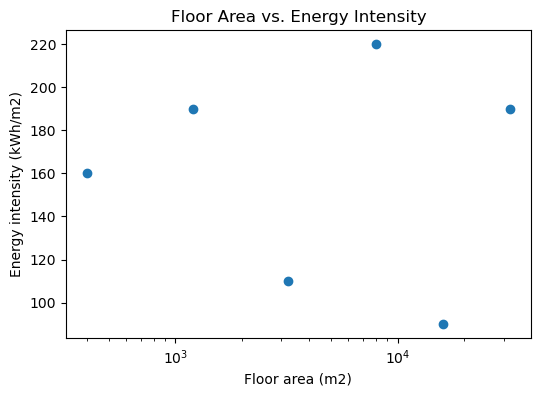

building                   Oak
use                 Laboratory
year                      2025
floor_area_m2             8000
electricity_kWh        1760000
energy_intensity         220.0
Name: 9, dtype: object

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    latest["floor_area_m2"],
    latest["energy_intensity"]
)

ax.set_xscale("log")

ax.set_xlabel("Floor area (m2)")
ax.set_ylabel("Energy intensity (kWh/m2)")
ax.set_title("Floor Area vs. Energy Intensity")

plt.show()

largest_building = latest.loc[latest["floor_area_m2"].idxmax()]
highest_intensity = latest.loc[latest["energy_intensity"].idxmax()]

largest_building
highest_intensity

### B. Follow one building over time (1 pt)

From the full `energy` table, select the building named in `energy_settings["trend_building"]`.
Sort its rows by year before making a line plot of energy intensity versus year, with a marker
at each observed year. Use a linear year axis.

Describe the trend. Would this plot alone establish that an energy-saving renovation caused
the change? Give one reason for your answer.

**Answer:**

Describe the trend. Would this plot alone establish that an energy-saving renovation caused
the change? Give one reason for your answer.

The energy intensity of the Maple building generally decreases over time, indicating that the building used less electricity per square meter in the later years.

However, this plot alone cannot establish that an energy-saving renovation caused the decrease. The plot only shows an association over time and does not provide evidence about the cause of the change. Other factors, such as weather, occupancy, operating hours, or changes in building use, could also affect energy consumption.

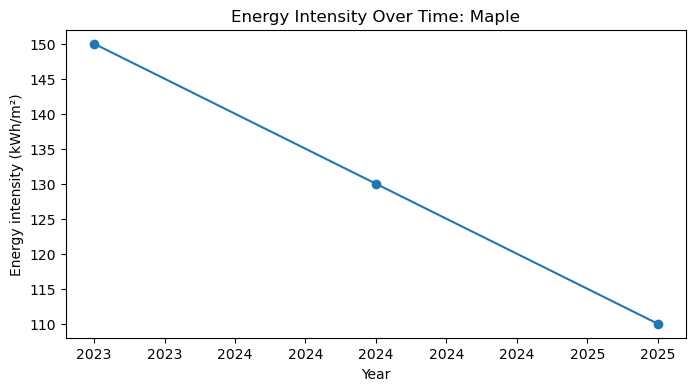

In [11]:
trend = energy.loc[
    energy["building"] == energy_settings["trend_building"]
].copy()

trend = trend.sort_values("year")

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    trend["year"],
    trend["energy_intensity"],
    marker="o"
)

ax.set_xlabel("Year")
ax.set_ylabel("Energy intensity (kWh/m²)")
ax.set_title(f'Energy Intensity Over Time: {energy_settings["trend_building"]}')
ax.xaxis.set_major_formatter(plt.FormatStrFormatter("%.0f"))

plt.show()

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA4",
  "export_n": 1,
  "session_date": "2026-09-29",
  "messages": [
    {"i": 1, "who": "student", "text": "so this is a first taks and this is how i did it we cans ee that the second one is more precies beucase it has lower bias and the mean value is closer the therefecene value but i want to check for my coding pracise:\n\nreference_mm = 25.000\ncalibration = pd.DataFrame({\n    \"A_mm\": [25.12, 25.10, 25.14, 25.11, 25.13,\n             25.09, 25.12, 25.11, 25.13, 25.10],\n    \"B_mm\": [24.92, 25.06, 24.97, 25.12, 24.89,\n             25.03, 25.08, 24.95, 25.00, 24.98],\n})\n\n# Your summary table here. Report lengths, s, and estimated bias in mm.\nsummary = {\n    \"mean\": [calibration[\"A_mm\"].mean(), calibration[\"B_mm\"].mean()],\n    \"std\":[calibration[\"A_mm\"].std(), calibration[\"B_mm\"].std()],\n    \"bias\":[(calibration[\"A_mm\"].mean() - reference_mm), (calibration[\"B_mm\"].mean() - reference_mm)],\n}\n\nprint(summary)", "code": true},
    {"i": 2, "who": "tutor", "text": "Confirmed bias direction and use of reference_mm were correct. Noted pandas .std() defaults to ddof=1 unlike NumPy. Noted a printed dict has no row labels and showed generic syntax for a labeled DataFrame index. Explained that precision comes from the spread (s) while bias comes from the mean, so the two questions can have different answers, and asked which s was smaller."},
    {"i": 3, "who": "student", "text": "reference_mm = 25.000\ncalibration = pd.DataFrame({\n    \"A_mm\": [25.12, 25.10, 25.14, 25.11, 25.13,\n             25.09, 25.12, 25.11, 25.13, 25.10],\n    \"B_mm\": [24.92, 25.06, 24.97, 25.12, 24.89,\n             25.03, 25.08, 24.95, 25.00, 24.98],\n})\n\n# Your summary table here. Report lengths, s, and estimated bias in mm.\nsummary = pd.DataFrame ({\n    \"mean\" : calibration.mean(),\n    \"std\" : calibration.std(),\n})\n\nsummary[\"bias\"] = summary[\"mean\"] - reference_mm\n\nprint(summary)\n\nprint(\"The second instrument has a mean value closer to the true reference value, since its estimated bias is zero.\")", "code": true},
    {"i": 4, "who": "tutor", "text": "Confirmed the labeled table and the reference values: mean A 25.115 mm, mean B 25.000 mm, bias A +0.115 mm, bias B 0.000 mm, s A 0.0158 mm, s B 0.0727 mm. Noted the precision question was still unanswered and that it comes from the s column. Noted the written answer belongs in the **Answer:** field and that instruments should be named by column label."},
    {"i": 5, "who": "student", "text": "Which instrument is more precise?\nThe first instrument is more precise because it has a lower standard deviation compared with the second instrument. However, it has a nonzero bias, which means that its measurements are not centered on the true reference value.\n\nWhich sample mean is closer to the reference?\nThe second instrument has a mean value closer to the true reference value, since its estimated bias is zero."},
    {"i": 6, "who": "tutor", "text": "Confirmed both questions now answered with the right statistic behind each. Suggested naming instruments A_mm and B_mm to match the table labels, and optionally citing the computed values. Reminded to move the paragraphs into the **Answer:** field."},
    {"i": 7, "who": "student", "text": "okay i fixed it"},
    {"i": 8, "who": "tutor", "text": "Acknowledged and offered to continue to LE4-1B or stop and make a record."},
    {"i": 9, "who": "student", "text": "### B. Apply a calibration correction (1 pt)\n\nSubtract A's estimated bias from every A reading and store the result in `corrected_A`.\nCompare its mean and sample $s$ with the original A readings.\n\nWhat changed, and what stayed the same? Would simply collecting more **uncorrected**\nreadings remove a persistent bias?\n\n**Answer:**\n\n1. What changed, and what stayed the same?\n\nWith this adjustment, the mean value of Instrument A changes and the estimated bias becomes zero, as expected. However, the standard deviation stays the same. This means that correcting for the known bias improves the accuracy of the measurements, while the precision remains unchanged.\n\n2. Would simply collecting more **uncorrected** readings remove a persistent bias?\n\nNo. Collecting more data would not remove the bias because the bias is inherent to the measurement process or instrument rather than caused by random variation in the data. Collecting more measurements can provide a more reliable estimate of the mean and reduce the standard error, but a persistent bias will remain unless the instrument is calibrated or corrected.\n\nA_bias = summary[\"bias\"].iloc[0]\n\ncorrected_A = calibration[\"A_mm\"] - A_bias\n\nsummary.loc[\"corrected_A\"] = [\n    corrected_A.mean(),\n    corrected_A.std(),\n    corrected_A.mean() - reference_mm\n]\n\nsummary", "code": true},
    {"i": 10, "who": "tutor", "text": "Confirmed corrected mean 25.000 mm and unchanged s 0.0158 mm. Noted both written answers did the right work, naming a statistic for what stayed the same and separating persistent offset from random variation. Flagged summary[\"bias\"].iloc[0] as selection by row position against the Setup requirement and showed generic df.loc[\"row_label\", \"column_name\"], explaining .loc labels versus .iloc positions."},
    {"i": 11, "who": "student", "text": "resistance_values = np.array([\n    100.1, 99.9, 100.0, 100.2, 100.1, 99.8, 100.0, 100.1, 102.4, 99.9,\n    100.2, 100.0, 99.8, 100.1, 100.0, 100.2, 100.1, 101.1, 99.9, 100.0,\n])\nlog_status = [\n    \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"loose_lead\", \"none\",\n    \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"none\", \"none\",\n]\nreadings = pd.DataFrame({\n    \"reading_id\": [f\"R{number:02d}\" for number in range(1, len(resistance_values) + 1)],\n    \"resistance_ohm\": resistance_values,\n    \"log_status\": log_status,\n})\nresistance_settings = {\n    \"outlier_multiplier\": 1.5,\n    \"fault_status\": \"loose_lead\",\n    \"lower_ohm\": 99.8,\n    \"upper_ohm\": 100.2,\n}\n\n# Your IQR calculation, Boolean mask, and flagged-reading table here\nq1 = readings[\"resistance_ohm\"].quantile(0.25)\nq3 = readings[\"resistance_ohm\"].quantile(0.75)\niqr = q3 - q1\n\nlower_bound = q1 - resistance_settings[\"outlier_multiplier\"] * iqr\nupper_bound = q3 + resistance_settings[\"outlier_multiplier\"] * iqr\n\nis_outlier = (\n    (readings[\"resistance_ohm\"] < lower_bound) |\n    (readings[\"resistance_ohm\"] > upper_bound)\n)\n\nflagged_readings = readings.loc[\n    is_outlier,\n    [\"reading_id\", \"resistance_ohm\", \"log_status\"]\n]\n\nflagged_readings", "code": true},
    {"i": 12, "who": "tutor", "text": "Confirmed against reference run: Q1 99.975, Q3 100.125, IQR 0.15 ohms, fences 99.75 and 100.35 ohms, flagging R09 and R18. Noted correct use of the settings multiplier, | with parenthesized conditions, correct mask orientation, .loc[] leaving readings intact, and log_status included in the display. Nothing to fix."},
    {"i": 13, "who": "student", "text": "### B. Exclude a documented failure (1 pt)\n\nCreate `retained_readings` by excluding **only the reading with the logged loose lead**.\nSelect it by `log_status`, not by its row position or resistance value.\nCompare the count, mean, and sample $s$ for all readings and the retained readings in one table.\n\nCompare the absolute changes, in ohms, in the mean and $s$. Which is larger?\nDoes an IQR flag alone justify excluding the other unusual reading? Explain briefly.\n\n**Answer:**\n\n1. Compare the absolute changes, in ohms, in the mean and $s$. Which is larger?\n\nAfter excluding the reading with the documented loose lead, the mean decreased from 100.195 Ω to 100.079 Ω, which is an absolute change of about 0.116 Ω. The standard deviation decreased from 0.584 Ω to 0.276 Ω, which is an absolute change of about 0.308 Ω. Therefore, the change in the standard deviation is larger.\n\nRemoving the faulty reading reduces the spread of the measurements substantially because the 102.4 Ω observation was far from most of the other readings. The mean also decreases, but by a smaller amount.\n\n2. Does an IQR flag alone justify excluding the other unusual reading? Explain briefly.\n\nNo. Although the IQR method also flags R18 as unusual, an IQR flag alone is not enough evidence to remove the observation. Unlike the reading with the loose lead, there is no documented measurement failure associated with R18. It may represent a legitimate but unusual measurement, so it should be investigated rather than automatically excluded."},
    {"i": 14, "who": "tutor", "text": "Confirmed all figures matched the reference run and that the values implied exactly R09 was excluded. Noted the flag-versus-evidence distinction was correctly drawn and units were given throughout. Explained why s moves more than the mean (squared deviation in the variance sum). Noted Ω versus ohms consistency and asked for the code cell to check the exclusion used log_status and the settings key."},
    {"i": 15, "who": "student", "text": "retained_readings = readings[readings[\"log_status\"] != \"loose_lead\"]\n\ncomparison = pd.DataFrame({\n    \"count\" : [readings[\"reading_id\"].count(), retained_readings[\"reading_id\"].count()],\n    \"mean\"  : [readings[\"resistance_ohm\"].mean(), retained_readings[\"resistance_ohm\"].mean()],\n    \"std\"   : [readings[\"resistance_ohm\"].std(), retained_readings[\"resistance_ohm\"].std()]\n}, index=[\"regular_readings\", \"retained_readings\"])\n\ncomparison", "code": true},
    {"i": 16, "who": "tutor", "text": "Confirmed the exclusion selects by documented cause and that counts came from .count(). Flagged the hard-coded \"loose_lead\" string against the Setup requirement and pointed to resistance_settings[\"fault_status\"], with generic syntax. Suggested renaming the row label to all_readings to match the prompt's language."},
    {"i": 17, "who": "student", "text": "1. Is the model percentage too low, too high, or close for this interval?\n\nThe observed percentage of retained readings between 99.8 and 100.2, including both endpoints, is approximately 94.74%. The fitted normal model predicts approximately 51.34% of readings within this interval. Therefore, the normal-model percentage is much too low compared with the observed percentage.\nThis difference occurs because most of the measurements are tightly concentrated between 99.8 and 100.2, while the unusual 101.1 reading increases the sample standard deviation. As a result, the fitted normal distribution is more spread out than most of the observed data.\n\n2. Why would even a good normal fit fail to establish that the instrument is unbiased?\n\nEven if the normal model fit the data well, this would not establish that the instrument is unbiased. A normal distribution describes the shape and spread of the measurements, but bias concerns whether the center of the measurements corresponds to the true resistance. Since the exact resistance of the resistor is unknown, we cannot determine whether the instrument's mean is centered on the true value.\n\nmean = retained_readings[\"resistance_ohm\"].mean()\nstd = retained_readings[\"resistance_ohm\"].std()\n\nnormal_model = norm(loc=mean, scale=std)\n\nlower = 99.8\nupper = 100.2\n\nwithin_interval = (\n    (retained_readings[\"resistance_ohm\"] >= lower) &\n    (retained_readings[\"resistance_ohm\"] <= upper)\n)\n\nobserved_percent = within_interval.mean() * 100\n\nmodel_percent = (\n    normal_model.cdf(upper) -\n    normal_model.cdf(lower)\n) * 100\n\nobserved_percent, model_percent", "code": true},
    {"i": 18, "who": "tutor", "text": "Confirmed retained mean 100.079 ohms, s 0.276 ohms, observed 94.74%, model 51.34%, and that these values showed the model was fitted to the full retained set with inclusive operators. Noted the verdict correctly reported the gap as a result rather than a bug, and that the unbiasedness answer drew the right distinction. Confirmed scale took the standard deviation. Flagged the hard-coded interval endpoints against resistance_settings lower_ohm and upper_ohm. Suggested renaming mean and std to avoid confusion with the methods."},
    {"i": 19, "who": "student", "text": "buildings = pd.read_csv(\"data/buildings.csv\")\n\nenergy_settings = {\n    \"minimum_area_m2\": 3000,\n    \"high_intensity_kWh_m2\": 180,\n    \"trend_building\": \"Maple\",\n}\n\n# Your derived column, latest-year selection, and display here\nenergy = pd.DataFrame(buildings.assign(energy_intensity=buildings[\"electricity_kWh\"]/buildings[\"floor_area_m2\"]))\n\nlatest_year = energy[\"year\"].max()\n\nlatest = energy.loc[energy[\"year\"] == latest_year].copy()\n\nlatest[\n    [\"building\", \"electricity_kWh\", \"floor_area_m2\", \"energy_intensity\"]\n]", "code": true},
    {"i": 20, "who": "tutor", "text": "Confirmed the ratio direction, .assign() use, computed latest year via .max(), condition-based selection, and .copy(). Flagged that the display showed electricity_kWh where the prompt asks for use. Explained that .assign() already returns a new DataFrame so the pd.DataFrame() wrapper has no effect, and showed the lambda form of .assign() for chaining."},
    {"i": 21, "who": "student", "text": "buildings = pd.read_csv(\"data/buildings.csv\")\n\nenergy_settings = {\n    \"minimum_area_m2\": 3000,\n    \"high_intensity_kWh_m2\": 180,\n    \"trend_building\": \"Maple\",\n}\n\n# Your derived column, latest-year selection, and display here\nenergy = pd.DataFrame(buildings.assign(energy_intensity=buildings[\"electricity_kWh\"]/buildings[\"floor_area_m2\"]))\n\nlatest_year = energy[\"year\"].max()\n\nlatest = energy.loc[energy[\"year\"] == latest_year].copy()\n\nlatest[\n    [\"building\", \"use\", \"floor_area_m2\", \"energy_intensity\"]\n]", "code": true},
    {"i": 22, "who": "tutor", "text": "Confirmed part A complete. Noted a copy of buildings.csv is available in the project so reference values can be checked on request."},
    {"i": 23, "who": "student", "text": "filtered = latest.loc[(latest[\"floor_area_m2\"] >= 3000) & (latest[\"energy_intensity\"] > 180)]\nfiltered = filtered.sort_values(by = \"energy_intensity\", ascending=False)\n\nfiltered[[\"building\", \"use\", \"energy_intensity\"]]", "code": true},
    {"i": 24, "who": "tutor", "text": "Confirmed >= for \"at least\" and > for \"greater than\", parenthesized conditions joined with &, filtering from latest, and descending sort. Flagged 3000 and 180 as hard-coded against energy_settings minimum_area_m2 and high_intensity_kWh_m2, noting this was the fourth such case."},
    {"i": 25, "who": "student", "text": "usage = latest.groupby(\"use\").agg(\n    number_of_buildings = (\"use\", \"count\"),\n    mean_energy_intensity = (\"energy_intensity\", \"mean\")\n)\n\nusage", "code": true},
    {"i": 26, "who": "tutor", "text": "Confirmed named aggregation gives descriptive column names, that all of latest was grouped rather than the part B subset, and that energy_intensity was aggregated. Suggested .reset_index() and explained \"size\" versus \"count\". Explained unweighted versus size-weighted means generically (each item contributes one rate value versus total numerator over total denominator) and asked for the two written answers."},
    {"i": 27, "who": "student", "text": "### C. Group and summarize (1 pt)\n\nUsing **all buildings in `latest`**, create one row per building `use` with the number\nof buildings and mean energy intensity. Use `.groupby(...).agg(...)` with descriptive column names.\n\nWhich use has the larger mean? Does this calculation give equal weight to each building\nor to each square meter of floor area?\n\n**Answer:**\n\nWhich use has the larger mean? \n\nThe buildings with laboratory use have the larger mean energy intensity.\n\nDoes this calculation give equal weight to each building or to each square meter of floor area?\n\nThis calculation gives equal weight to each building, not to each square meter of floor area. Each building contributes one energy-intensity value to the group mean regardless of its size. Therefore, a small building and a large building have the same influence on the calculated average."},
    {"i": 28, "who": "tutor", "text": "Confirmed both answers, including the laboratory claim against the data file. Noted the weighting answer correctly described what each row contributes rather than the code. Suggested optionally citing the two mean values."},
    {"i": 29, "who": "student", "text": "## LE4-4. Show a relationship and a time trend (2 pts)\n\nUse `energy` and `latest` from LE4-3. Label axes with units and give each plot a title.\n\n### A. Scatterplot with a log axis (1 pt)\n\nFor **all buildings in `latest`**, plot floor area on the x-axis and energy intensity\non the y-axis. Use `ax.set_xscale(\"log\")` because floor areas span a wide range.\n\nExplain what equal horizontal distances represent. Does the largest building have the\nhighest energy intensity in this snapshot?\n\n**Answer:**\n\nExplain what equal horizontal distances represent.\n\nOn a logarithmic x-axis, equal horizontal distances represent equal ratios rather than equal absolute differences. For example, moving from 1,000 to 10,000 m2 takes the same horizontal distance as moving from 10,000 to 100,000 m2.\n\nDoes the largest building have the highest energy intensity in this snapshot?\n\nThe largest building does not necessarily have the highest energy intensity. Floor area represents the size of the building, while energy intensity represents electricity use per square meter, so a larger building can still have a lower energy intensity than a smaller building.\n\nfig, ax = plt.subplots(figsize=(6, 4))\n\nax.scatter(\n    latest[\"floor_area_m2\"],\n    latest[\"energy_intensity\"]\n)\n\nax.set_xscale(\"log\")\n\nax.set_xlabel(\"Floor area (m²)\")\nax.set_ylabel(\"Energy intensity (kWh/m²)\")\nax.set_title(\"Floor Area vs. Energy Intensity\")\n\nplt.show()", "code": true},
    {"i": 30, "who": "tutor", "text": "Confirmed the plot met every printed requirement: labels with units, title, set_xscale on x, ax.scatter, all of latest. Confirmed the equal-distances answer. Flagged that the largest-building answer gave a general statement rather than a yes-or-no about this snapshot, and showed df.loc[df[\"col\"].idxmax()] and the sort_values alternative for checking. Noted m2 versus m² inconsistency."},
    {"i": 31, "who": "student", "text": "fig, ax = plt.subplots(figsize=(6, 4))\n\nax.scatter(\n    latest[\"floor_area_m2\"],\n    latest[\"energy_intensity\"]\n)\n\nax.set_xscale(\"log\")\n\nax.set_xlabel(\"Floor area (m2)\")\nax.set_ylabel(\"Energy intensity (kWh/m2)\")\nax.set_title(\"Floor Area vs. Energy Intensity\")\n\nplt.show()\n\nlargest_building = latest.loc[latest[\"floor_area_m2\"].idxmax()]\nhighest_intensity = latest.loc[latest[\"energy_intensity\"].idxmax()]\n\nlargest_building\nhighest_intensity", "code": true},
    {"i": 32, "who": "tutor", "text": "Confirmed .idxmax() was the right tool on both columns. Explained that Jupyter auto-displays only the last expression in a cell and showed display() as the fix so both rows are visible for comparison. Restated the unit-notation consistency point."},
    {"i": 33, "who": "student", "text": "oaky fiexed it"},
    {"i": 34, "who": "tutor", "text": "Acknowledged and offered to continue to LE4-4B or stop."},
    {"i": 35, "who": "student", "text": "### B. Follow one building over time (1 pt)\n\nFrom the full `energy` table, select the building named in `energy_settings[\"trend_building\"]`.\nSort its rows by year before making a line plot of energy intensity versus year, with a marker\nat each observed year. Use a linear year axis.\n\nDescribe the trend. Would this plot alone establish that an energy-saving renovation caused\nthe change? Give one reason for your answer.\n\n**Answer:**\n\nDescribe the trend. Would this plot alone establish that an energy-saving renovation caused\nthe change? Give one reason for your answer.\n\nThe energy intensity of the Maple building generally decreases over time, indicating that the building used less electricity per square meter in the later years.\n\nHowever, this plot alone cannot establish that an energy-saving renovation caused the decrease. The plot only shows an association over time and does not provide evidence about the cause of the change. Other factors, such as weather, occupancy, operating hours, or changes in building use, could also affect energy consumption.\n\ntrend = energy.loc[\n    energy[\"building\"] == energy_settings[\"trend_building\"]\n].copy()\n\ntrend = trend.sort_values(\"year\")\n\nfig, ax = plt.subplots(figsize=(8, 4))\n\nax.plot(\n    trend[\"year\"],\n    trend[\"energy_intensity\"],\n    marker=\"o\"\n)\n\nax.set_xlabel(\"Year\")\nax.set_ylabel(\"Energy intensity (kWh/m²)\")\nax.set_title(f'Energy Intensity Over Time: {energy_settings[\"trend_building\"]}')\n\nplt.show()", "code": true},
    {"i": 36, "who": "tutor", "text": "Confirmed selection from the full energy table, the settings lookup, exact equality, sort before plotting, markers, linear year axis, labels with units, and a title driven from the settings dictionary. Confirmed the causation answer named the association-versus-cause distinction with concrete confounders. Flagged the trend description as lacking magnitude and shape, and asked what the start and end values are, whether the decline is steady, and whether any year rises. Noted the shape also sharpens the second answer."},
    {"i": 37, "who": "student", "text": "fixed"},
    {"i": 38, "who": "tutor", "served": ["finishing"], "text": "Noted the assignment complete, served the finishing block, and listed the remaining hard-coded values to check: \"loose_lead\" in LE4-2B, the interval endpoints in LE4-2C, and 3000 and 180 in LE4-3B."}
  ],
  "events": [
    {"i": 1, "part": "4-1A", "type": "code"},
    {"i": 3, "part": "4-1A", "type": "code"},
    {"i": 7, "part": "4-1A", "type": "unstuck"},
    {"i": 7, "part": "4-1A", "type": "part_pass"},
    {"i": 9, "part": "4-1B", "type": "code"},
    {"i": 9, "part": "4-1B", "type": "part_pass"},
    {"i": 11, "part": "4-2A", "type": "code"},
    {"i": 11, "part": "4-2A", "type": "part_pass"},
    {"i": 13, "part": "4-2B", "type": "code"},
    {"i": 15, "part": "4-2B", "type": "code"},
    {"i": 15, "part": "4-2B", "type": "part_pass"},
    {"i": 17, "part": "4-2C", "type": "code"},
    {"i": 17, "part": "4-2C", "type": "part_pass"},
    {"i": 19, "part": "4-3A", "type": "code"},
    {"i": 21, "part": "4-3A", "type": "code"},
    {"i": 21, "part": "4-3A", "type": "part_pass"},
    {"i": 23, "part": "4-3B", "type": "code"},
    {"i": 23, "part": "4-3B", "type": "part_pass"},
    {"i": 25, "part": "4-3C", "type": "code"},
    {"i": 26, "part": "4-3C", "type": "explain"},
    {"i": 27, "part": "4-3C", "type": "part_pass"},
    {"i": 29, "part": "4-4A", "type": "code"},
    {"i": 31, "part": "4-4A", "type": "code"},
    {"i": 33, "part": "4-4A", "type": "unstuck"},
    {"i": 33, "part": "4-4A", "type": "part_pass"},
    {"i": 35, "part": "4-4B", "type": "code"},
    {"i": 37, "part": "4-4B", "type": "unstuck"},
    {"i": 37, "part": "4-4B", "type": "part_pass"}
  ],
  "parts": [
    {"part": "4-1A", "exchanges": 4, "max_tier": 3, "passed": true},
    {"part": "4-1B", "exchanges": 1, "max_tier": 3, "passed": true},
    {"part": "4-2A", "exchanges": 1, "max_tier": 1, "passed": true},
    {"part": "4-2B", "exchanges": 2, "max_tier": 3, "passed": true},
    {"part": "4-2C", "exchanges": 1, "max_tier": 3, "passed": true},
    {"part": "4-3A", "exchanges": 2, "max_tier": 3, "passed": true},
    {"part": "4-3B", "exchanges": 1, "max_tier": 3, "passed": true},
    {"part": "4-3C", "exchanges": 2, "max_tier": 2, "passed": true},
    {"part": "4-4A", "exchanges": 3, "max_tier": 3, "passed": true},
    {"part": "4-4B", "exchanges": 2, "max_tier": 3, "passed": true}
  ],
  "tutor_assessment": [
    "The longest stall was LE4-1A, where the student's opening answer used bias as the reason for precision and named a single instrument for both questions. The sticking point was conceptual rather than computational: separating spread from center. Once precision and bias were explained as distinct properties and the two s values were pointed at, the student produced a correct two-part answer and carried the distinction cleanly through LE4-1B and LE4-2C. A second recurring pattern across the session was not a stall but a habit: hard-coded values where the supplied settings dictionaries carried them, flagged four separate times in LE4-2B, LE4-2C, and LE4-3B. The student adopted the lookup habit in LE4-4B without prompting, but the earlier cells were never confirmed fixed. A third pattern was answering a data-specific question with a general principle, which happened in LE4-4A on the largest-building question and partially in LE4-4B on the trend description.",
    "No release-valve use occurred. Three steps closed on brief 'fixed' or 'okay i fixed it' declarations (4-1A, 4-4A, 4-4B) without the corrected work being shown. None looks like a tutoring failure: each followed a specific, narrow correction the student had visibly understood in the preceding exchange. The one worth noting is 4-4B, where the trend description was closed on 'fixed' immediately after being told it lacked magnitude and shape, so there is no record of what the student wrote. The same applies to 4-4A's yes-or-no verdict. In both cases the graded prose is unverified, which is a limitation of the record rather than of the tutoring. No step saw repeated escape-hatch use."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.